<a href="https://colab.research.google.com/github/Mathildeholst/Speciale/blob/main/Speciale_kode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speciale

Fordelingen af data

For-rerec

Training
Real:5104
Fake:5104

Validation
Real:1101
Fake:1143

Test:
Real:408
Fake:408

###Download the data from Google Drev


Connects Google Colab to Google Drive so the dataset stored in Drive can be accessed

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Define the main folder path where the dataset is stored in Google Drive

In [2]:
!cp -r "/content/drive/MyDrive/Speciale/for-rerecorded 2" /content/for-rerec

In [3]:
base_path = "/content/for-rerec"

Check the dataset structure

In [4]:
import os

os.listdir("/content/for-rerec")

['training', 'testing', 'validation', 'for-rerecorded 2']

Define paths for each dataset split

In [5]:
train_path = "/content/for-rerec/for-rerecorded 2/training"
val_path   = "/content/for-rerec/for-rerecorded 2/validation"
test_path  = "/content/for-rerec/for-rerecorded 2/testing"

Count files in each folder

In [6]:
import os
import pandas as pd

data = []

for split in ["training", "validation", "testing"]:
    for label in ["real", "fake"]:
        path = f"{base_path}/{split}/{label}"
        count = len(os.listdir(path))
        data.append([split, label, count])

df = pd.DataFrame(data, columns=["Dataset", "Class", "Count"])
df

,Dataset,Class,Count
0,training,real,5104
1,training,fake,5104
2,validation,real,1101
3,validation,fake,1143
4,testing,real,408
5,testing,fake,408


###Create Mel spectogrammer

Lav Mel spectogram på første 5 real og fake i train, for at se hvordan det ser ud

In [7]:
!pip install librosa

In [8]:
!ls "/content/for-rerec"

'for-rerecorded 2'   testing   training   validation


In [9]:
import os
import numpy as np
import librosa

def get_all_wav_paths(split, label):
    folder = os.path.join(base_path, split, label)
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".wav")]
    files.sort()
    return files


# -------- TRAIN --------

train_real = get_all_wav_paths("training", "real")
train_fake = get_all_wav_paths("training", "fake")

# -------- VALIDATION --------

val_real = get_all_wav_paths("validation", "real")
val_fake = get_all_wav_paths("validation", "fake")

# -------- TEST --------

test_real = get_all_wav_paths("testing", "real")
test_fake = get_all_wav_paths("testing", "fake")


def create_mel_spectrogram(file_path, sr=16000, n_mels=128, duration=2.0):

    # Load only the first 2 seconds
    audio, _ = librosa.load(file_path, sr=sr, duration=duration)

    # Pad if shorter than 2 seconds
    target_len = int(sr * duration)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]

    # Create mel spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)

    # Convert to dB
    mel_db = librosa.power_to_db(mel, ref=np.max)

    return mel_db

# Make spectrograms for first 5 real + 5 fake
mel_specs = []
labels = []

for fp in train_real[:5]:
    mel_specs.append(create_mel_spectrogram(fp))
    labels.append(1)  # real = 1

for fp in train_fake[:5]:
    mel_specs.append(create_mel_spectrogram(fp))
    labels.append(0)  # fake = 0

print("Number of spectrograms:", len(mel_specs))
print("Shape example:", mel_specs[0].shape)
print("Labels:", labels)

Number of spectrograms: 10
Shape example: (128, 63)
Labels: [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


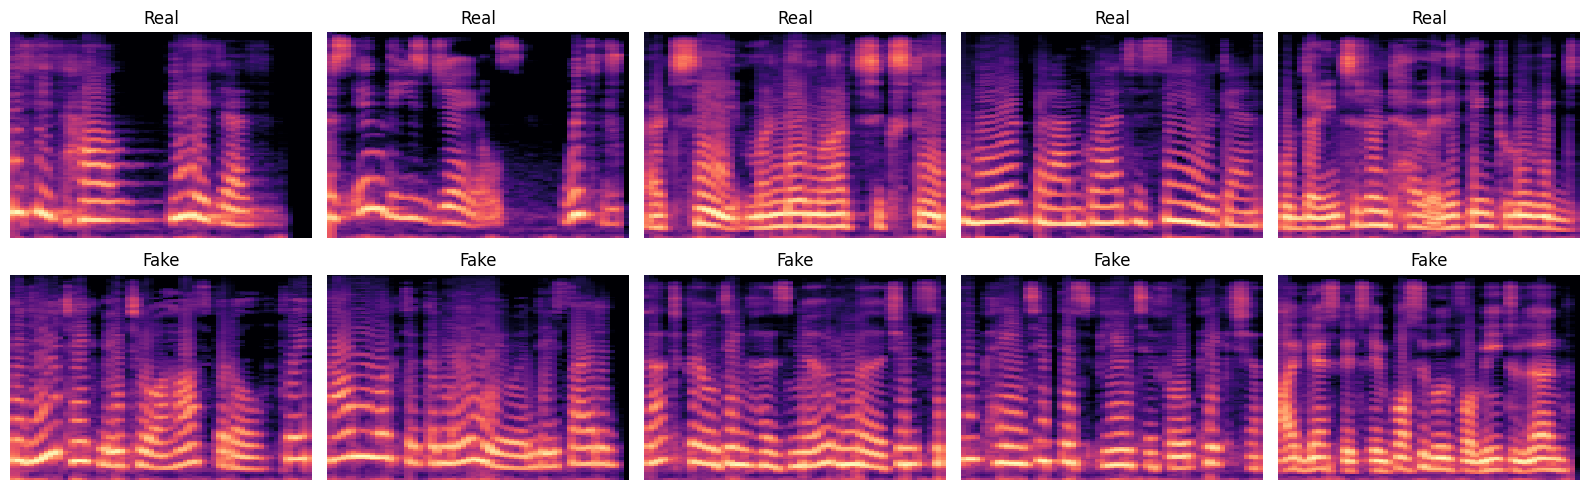

In [15]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(16,5))

for i, spec in enumerate(mel_specs):

    plt.subplot(2,5,i+1)  # 2 rows, 5 columns

    librosa.display.specshow(spec, x_axis="time", y_axis="mel")

    plt.title("Real" if labels[i]==1 else "Fake")
    plt.axis("off")

plt.tight_layout()
plt.show()

Lave spectrogrammer for hele training-datasættet

Training spectrograms

In [10]:
mel_specs_train = []
labels_train = []

# Real audio
for i, fp in enumerate(train_real):
    mel_specs_train.append(create_mel_spectrogram(fp))
    labels_train.append(1)

    if (i+1) % 500 == 0:
        print("Processed train real:", i+1)

# Fake audio
for i, fp in enumerate(train_fake):
    mel_specs_train.append(create_mel_spectrogram(fp))
    labels_train.append(0)

    if (i+1) % 500 == 0:
        print("Processed train fake:", i+1)

print("Total train spectrograms:", len(mel_specs_train))

Processed train real: 500
Processed train real: 1000
Processed train real: 1500
Processed train real: 2000
Processed train real: 2500
Processed train real: 3000
Processed train real: 3500
Processed train real: 4000
Processed train real: 4500
Processed train real: 5000
Processed train fake: 500
Processed train fake: 1000
Processed train fake: 1500
Processed train fake: 2000
Processed train fake: 2500
Processed train fake: 3000
Processed train fake: 3500
Processed train fake: 4000
Processed train fake: 4500
Processed train fake: 5000
Total train spectrograms: 10208


Validation spectrograms

In [11]:
mel_specs_val = []
labels_val = []

for fp in val_real:
    mel_specs_val.append(create_mel_spectrogram(fp))
    labels_val.append(1)

for fp in val_fake:
    mel_specs_val.append(create_mel_spectrogram(fp))
    labels_val.append(0)

print("Total validation spectrograms:", len(mel_specs_val))

Total validation spectrograms: 2244


Test spectrograms

In [12]:
mel_specs_test = []
labels_test = []

for fp in test_real:
    mel_specs_test.append(create_mel_spectrogram(fp))
    labels_test.append(1)

for fp in test_fake:
    mel_specs_test.append(create_mel_spectrogram(fp))
    labels_test.append(0)

print("Total test spectrograms:", len(mel_specs_test))

Total test spectrograms: 816


Konverter til arrays

* X = spectrogram billeder

* y = labels

In [13]:
X_train = np.array(mel_specs_train)[..., np.newaxis]
y_train = np.array(labels_train)

X_val = np.array(mel_specs_val)[..., np.newaxis]
y_val = np.array(labels_val)

X_test = np.array(mel_specs_test)[..., np.newaxis]
y_test = np.array(labels_test)

# Scale spectrograms from [-80, 0] → [0, 1]
X_train = (X_train + 80) / 80
X_val   = (X_val + 80) / 80
X_test  = (X_test + 80) / 80

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(10208, 128, 63, 1)
(2244, 128, 63, 1)
(816, 128, 63, 1)


In [21]:
print("Unique train shapes:", {x.shape for x in mel_specs_train})
print("Unique val shapes:", {x.shape for x in mel_specs_val})
print("Unique test shapes:", {x.shape for x in mel_specs_test})

Unique train shapes: {(128, 63)}
Unique val shapes: {(128, 63)}
Unique test shapes: {(128, 63)}


In [22]:
print("NaN in X_train:", np.isnan(X_train).any())
print("NaN in X_val:", np.isnan(X_val).any())
print("NaN in X_test:", np.isnan(X_test).any())

print("Inf in X_train:", np.isinf(X_train).any())
print("Inf in X_val:", np.isinf(X_val).any())
print("Inf in X_test:", np.isinf(X_test).any())

NaN in X_train: False
NaN in X_val: False
NaN in X_test: False
Inf in X_train: False
Inf in X_val: False
Inf in X_test: False


In [23]:
print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_test min/max:", X_test.min(), X_test.max())

X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_test min/max: 0.0 1.0


In [24]:
print("Train/Val real overlap:", len(set(train_real).intersection(set(val_real))))
print("Train/Test real overlap:", len(set(train_real).intersection(set(test_real))))
print("Val/Test real overlap:", len(set(val_real).intersection(set(test_real))))

print("Train/Val fake overlap:", len(set(train_fake).intersection(set(val_fake))))
print("Train/Test fake overlap:", len(set(train_fake).intersection(set(test_fake))))
print("Val/Test fake overlap:", len(set(val_fake).intersection(set(test_fake))))

Train/Val real overlap: 0
Train/Test real overlap: 0
Val/Test real overlap: 0
Train/Val fake overlap: 0
Train/Test fake overlap: 0
Val/Test fake overlap: 0


##Baseline model

In [53]:
import tensorflow as tf
from tensorflow.keras import layers, models

baseline_cnn = models.Sequential([

    layers.Input(shape=(128, 63, 1)),

    layers.Conv2D(8, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(16, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

baseline_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_cnn.summary()

history = baseline_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 61, 8)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 30, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 28, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6720)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │       107,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 45s 136ms/step - accuracy: 0.6872 - loss: 0.5645 - val_accuracy: 0.8819 - val_loss: 0.3223
Epoch 2/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.8679 - loss: 0.3126 - val_accuracy: 0.9158 - val_loss: 0.2365
Epoch 3/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 41s 129ms/step - accuracy: 0.9151 - loss: 0.2174 - val_accuracy: 0.9372 - val_loss: 0.1796
Epoch 4/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.9379 - loss: 0.1573 - val_accuracy: 0.9434 - val_loss: 0.1532
Epoch 5/5
319/319 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.9553 - loss: 0.1306 - val_accuracy: 0.9345 - val_loss: 0.1663


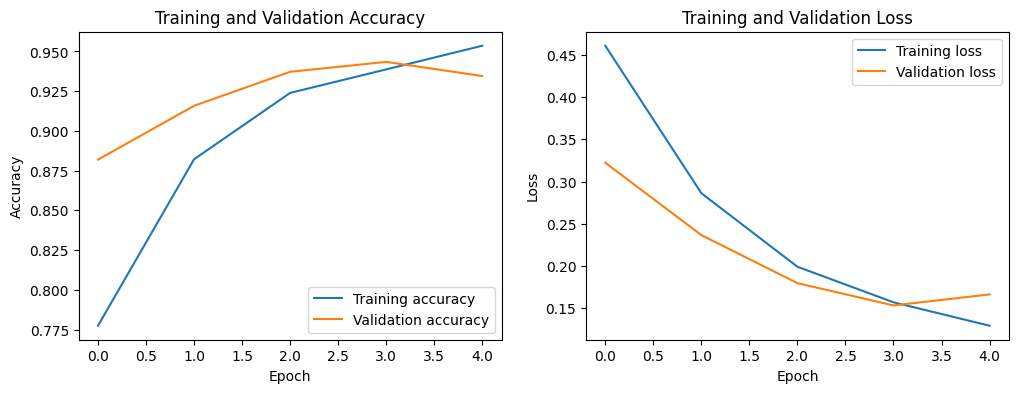

In [54]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Koderne nedenunder tester at alt er fint

In [55]:
set(train_real).intersection(set(val_real))
set(train_fake).intersection(set(val_fake))

set()

In [56]:
print("Train real:", len(train_real))
print("Train fake:", len(train_fake))

print("Validation real:", len(val_real))
print("Validation fake:", len(val_fake))

Train real: 5104
Train fake: 5104
Validation real: 1101
Validation fake: 1143


In [57]:
print(np.std(X_train))

0.21317407


Lave confusion matrix på validation

71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step


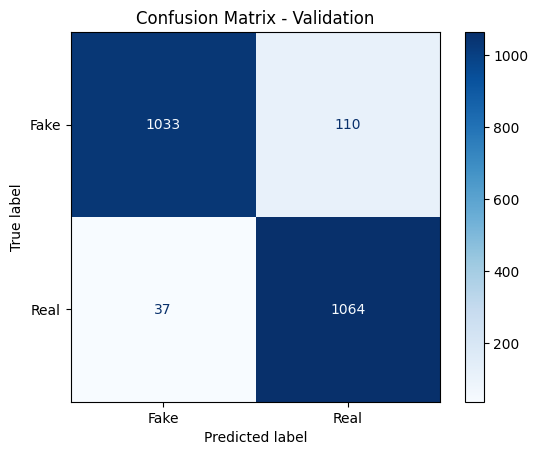

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on validation
y_prob_val = baseline_cnn.predict(X_val)
y_pred_val = (y_prob_val > 0.5).astype(int)

cm_val = confusion_matrix(y_val, y_pred_val)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["Fake", "Real"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Validation")
plt.show()

Hvis man skal teste på test

In [61]:
test_loss, test_acc = baseline_cnn.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

Test accuracy: 0.7977941036224365
Test loss: 0.4940009117126465


Lave confusion matrix på test

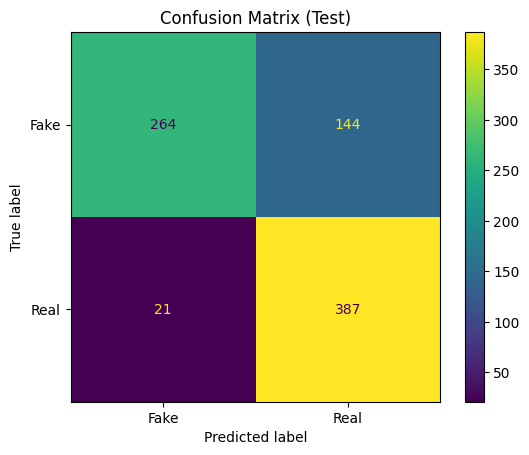

In [63]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_prob = baseline_cnn.predict(X_test, verbose=0)
y_pred = (y_prob >= 0.5).astype(int).ravel()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Fake", "Real"])
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()

Din confusion matrix viser at modellen mister mange fakes (FN ~35%).
Så du kan skrive at baseline især har forbedringspotentiale på deepfake recall (det passer med jeres fokus).

## Bedre model

In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = X_train.shape[1:]

better_baseline = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

better_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

better_baseline.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 128, 63, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 64, 31, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 7168)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7168)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │       229,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,737 (987.25 KB)

 Trainable params: 252,737 (987.25 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_better_baseline.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [46]:
history = better_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6281 - loss: 0.6253
Epoch 1: val_loss improved from inf to 0.36724, saving model to best_better_baseline.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 89s 271ms/step - accuracy: 0.6284 - loss: 0.6250 - val_accuracy: 0.8525 - val_loss: 0.3672 - learning_rate: 3.0000e-04
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.8394 - loss: 0.3697
Epoch 2: val_loss improved from 0.36724 to 0.28999, saving model to best_better_baseline.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 133s 243ms/step - accuracy: 0.8394 - loss: 0.3697 - val_accuracy: 0.8881 - val_loss: 0.2900 - learning_rate: 3.0000e-04
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8871 - loss: 0.2848
Epoch 3: val_loss improved from 0.28999 to 0.22441, saving model to best_better_baseline.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 77s 242ms/step - accuracy: 0.8872 - loss: 0.2848 - val_accuracy: 0.9109 - val_loss: 0.2244 - learning_rate: 3.0000e-04
Epoch 4/10

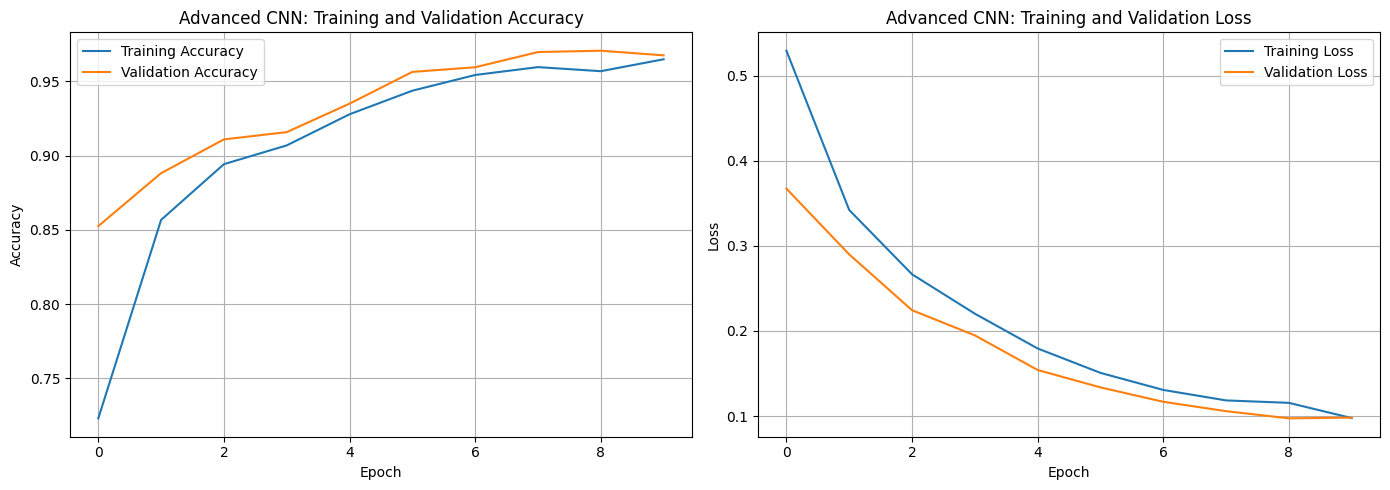

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Advanced CNN: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Advanced CNN: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [48]:
best_model = tf.keras.models.load_model("best_better_baseline.keras")

In [49]:
test_loss, test_acc = best_model.evaluate(X_test, y_test)
print("Best model test loss:", test_loss)
print("Best model test accuracy:", test_acc)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8717 - loss: 0.3399
Best model test loss: 0.48675674200057983
Best model test accuracy: 0.8174019455909729


In [52]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred_prob = best_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step
[[298 110]
 [ 39 369]]
              precision    recall  f1-score   support

        Fake       0.88      0.73      0.80       408
        Real       0.77      0.90      0.83       408

    accuracy                           0.82       816
   macro avg       0.83      0.82      0.82       816
weighted avg       0.83      0.82      0.82       816



##Nye spectogrammer:

In [53]:
import librosa
import numpy as np

def create_mel_spectrogram(file_path, sr=16000, n_mels=128, duration=2.0, n_fft=1024, hop_length=256):

    audio, _ = librosa.load(file_path, sr=sr)

    target_len = int(sr * duration)

    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    return mel_db

In [54]:
mel_specs_train = []
labels_train = []

for i, fp in enumerate(train_real):
    mel_specs_train.append(create_mel_spectrogram(fp))
    labels_train.append(1)

    if (i+1) % 500 == 0:
        print("Processed train real:", i+1)

for i, fp in enumerate(train_fake):
    mel_specs_train.append(create_mel_spectrogram(fp))
    labels_train.append(0)

    if (i+1) % 500 == 0:
        print("Processed train fake:", i+1)

print("Total train spectrograms:", len(mel_specs_train))

Processed train real: 500
Processed train real: 1000
Processed train real: 1500
Processed train real: 2000
Processed train real: 2500
Processed train real: 3000
Processed train real: 3500
Processed train real: 4000
Processed train real: 4500
Processed train real: 5000
Processed train fake: 500
Processed train fake: 1000
Processed train fake: 1500
Processed train fake: 2000
Processed train fake: 2500
Processed train fake: 3000
Processed train fake: 3500
Processed train fake: 4000
Processed train fake: 4500
Processed train fake: 5000
Total train spectrograms: 10208


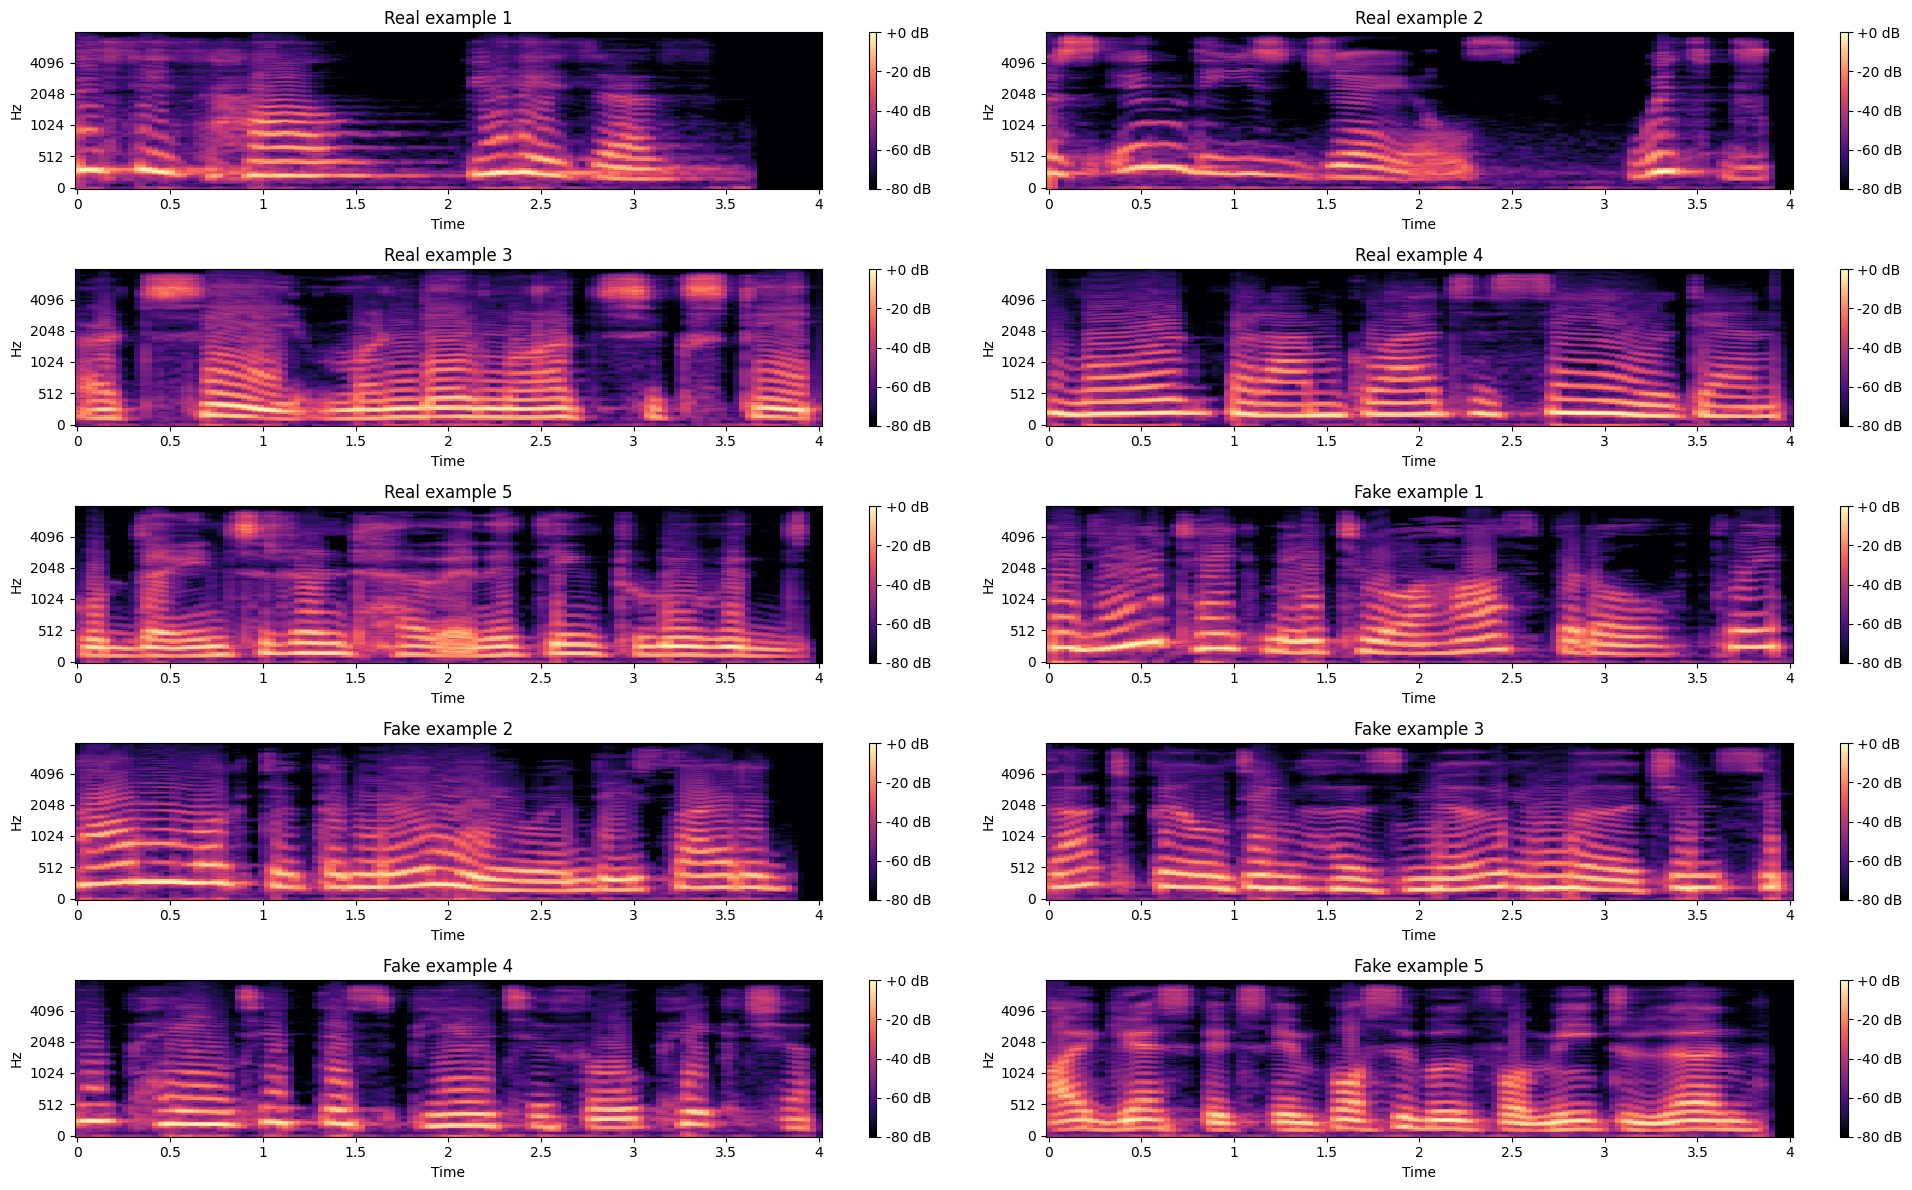

In [55]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(20, 12))

# 5 real
for i in range(5):
    plt.subplot(5, 2, i + 1)
    librosa.display.specshow(mel_specs_train[i], sr=16000, x_axis="time", y_axis="mel")
    plt.title(f"Real example {i+1}")
    plt.colorbar(format="%+2.0f dB")

# 5 fake
fake_start = labels_train.index(0)  # first fake starts here

for i in range(5):
    plt.subplot(5, 2, i + 6)
    librosa.display.specshow(mel_specs_train[fake_start + i], sr=16000, x_axis="time", y_axis="mel")
    plt.title(f"Fake example {i+1}")
    plt.colorbar(format="%+2.0f dB")

plt.tight_layout()
plt.show()

In [56]:
mel_specs_val = []
labels_val = []

for fp in val_real:
    mel_specs_val.append(create_mel_spectrogram(fp))
    labels_val.append(1)

for fp in val_fake:
    mel_specs_val.append(create_mel_spectrogram(fp))
    labels_val.append(0)

print("Total validation spectrograms:", len(mel_specs_val))

Total validation spectrograms: 2244


In [57]:
mel_specs_test = []
labels_test = []

for fp in test_real:
    mel_specs_test.append(create_mel_spectrogram(fp))
    labels_test.append(1)

for fp in test_fake:
    mel_specs_test.append(create_mel_spectrogram(fp))
    labels_test.append(0)

print("Total test spectrograms:", len(mel_specs_test))

Total test spectrograms: 816


In [58]:
X_train = np.array(mel_specs_train)[..., np.newaxis]
y_train = np.array(labels_train)

X_val = np.array(mel_specs_val)[..., np.newaxis]
y_val = np.array(labels_val)

X_test = np.array(mel_specs_test)[..., np.newaxis]
y_test = np.array(labels_test)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (10208, 128, 126, 1)
Validation shape: (2244, 128, 126, 1)
Test shape: (816, 128, 126, 1)


In [59]:
X_train = (X_train + 80) / 80
X_val   = (X_val + 80) / 80
X_test  = (X_test + 80) / 80

In [60]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = X_train.shape[1:]

stronger_cnn = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32,(3,3),activation="relu",padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation="relu",padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation="relu",padding="same"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dropout(0.4),

    layers.Dense(64,activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1,activation="sigmoid")
])

stronger_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

stronger_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 128, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 64, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 32, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 30720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     1,966,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,058,881 (7.85 MB)

 Trainable params: 2,058,881 (7.85 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_stronger_cnn.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [62]:
history = stronger_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6678 - loss: 0.5867
Epoch 1: val_loss improved from inf to 0.35428, saving model to best_stronger_cnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.6681 - loss: 0.5864 - val_accuracy: 0.8592 - val_loss: 0.3543 - learning_rate: 3.0000e-04
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8711 - loss: 0.3092
Epoch 2: val_loss improved from 0.35428 to 0.19934, saving model to best_stronger_cnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 394s 1s/step - accuracy: 0.8712 - loss: 0.3090 - val_accuracy: 0.9176 - val_loss: 0.1993 - learning_rate: 3.0000e-04
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9095 - loss: 0.2181
Epoch 3: val_loss improved from 0.19934 to 0.14682, saving model to best_stronger_cnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 361s 1s/step - accuracy: 0.9095 - loss: 0.2181 - val_accuracy: 0.9332 - val_loss: 0.1468 - learning_rate: 3.0000e-04
Epoch 4/10
319/319 ━━━━━━━━━━━━━━━━

In [63]:
best_model = tf.keras.models.load_model("best_stronger_cnn.keras")

test_loss, test_acc = best_model.evaluate(X_test,y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.8546 - loss: 0.4114
Test loss: 0.5193002820014954
Test accuracy: 0.8125


##Pretrained

In [23]:
IMG_SIZE = 160

def preprocess_for_mobilenet(x, y):

    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    x = tf.image.grayscale_to_rgb(x)

    return x, y

In [24]:
import tensorflow as tf

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.shuffle(2000).map(preprocess_for_mobilenet).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(preprocess_for_mobilenet).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.map(preprocess_for_mobilenet).batch(32).prefetch(tf.data.AUTOTUNE)

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(160, 160, 3))

# Preprocess input for MobileNetV2
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet_model = models.Model(inputs, outputs)

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_4 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_mobilenet.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [31]:
history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.8306 - loss: 0.3854
Epoch 1: val_loss improved from inf to 1.33127, saving model to best_mobilenet.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 253s 773ms/step - accuracy: 0.8306 - loss: 0.3854 - val_accuracy: 0.5094 - val_loss: 1.3313 - learning_rate: 3.0000e-04
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.7321 - loss: 0.6176
Epoch 2: val_loss improved from 1.33127 to 1.31751, saving model to best_mobilenet.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 282s 883ms/step - accuracy: 0.7324 - loss: 0.6172 - val_accuracy: 0.5094 - val_loss: 1.3175 - learning_rate: 3.0000e-04
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.7296 - loss: 0.6132
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

Epoch 3: val_loss did not improve from 1.31751
319/319 ━━━━━━━━━━━━━━━━━━━━ 242s 761ms/step - accuracy: 0.7299 - loss: 0.6127 - val_accuracy: 0.5094 - val_loss: 1.3666 - learning_rate: 3.

KeyboardInterrupt: 

In [ ]:
best_model = tf.keras.models.load_model("best_mobilenet.keras")

test_loss, test_acc = best_model.evaluate(X_test_pre, y_test, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

##MFCC

In [32]:
import os
import pandas as pd

base_path = "/content/for-rerec"

data = []

for split in ["training", "validation", "testing"]:
    for label in ["real", "fake"]:
        path = f"{base_path}/{split}/{label}"
        count = len([f for f in os.listdir(path) if f.endswith(".wav")])
        data.append([split, label, count])

df = pd.DataFrame(data, columns=["Dataset", "Class", "Count"])
df

,Dataset,Class,Count
0,training,real,5104
1,training,fake,5104
2,validation,real,1101
3,validation,fake,1143
4,testing,real,408
5,testing,fake,408


In [34]:
import os

def get_all_wav_paths(split, label):
    folder = os.path.join(base_path, split, label)
    files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".wav")]
    files.sort()
    return files

train_real = get_all_wav_paths("training", "real")
train_fake = get_all_wav_paths("training", "fake")

val_real = get_all_wav_paths("validation", "real")
val_fake = get_all_wav_paths("validation", "fake")

test_real = get_all_wav_paths("testing", "real")
test_fake = get_all_wav_paths("testing", "fake")

print(len(train_real), len(train_fake))
print(len(val_real), len(val_fake))
print(len(test_real), len(test_fake))

5104 5104
1101 1143
408 408


In [35]:
import librosa
import numpy as np

def create_mfcc_features(file_path, sr=16000, duration=2.0, n_mfcc=40, n_fft=1024, hop_length=256):
    audio, _ = librosa.load(file_path, sr=sr)

    target_len = int(sr * duration)
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length
    )

    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    features = np.vstack([mfcc, delta, delta2])  # shape: (120, time)
    return features

In [36]:
mfcc_train = []
labels_train = []

for i, fp in enumerate(train_real):
    mfcc_train.append(create_mfcc_features(fp))
    labels_train.append(1)

    if (i + 1) % 500 == 0:
        print("Processed train real:", i + 1)

for i, fp in enumerate(train_fake):
    mfcc_train.append(create_mfcc_features(fp))
    labels_train.append(0)

    if (i + 1) % 500 == 0:
        print("Processed train fake:", i + 1)

print("Total train samples:", len(mfcc_train))

Processed train real: 500
Processed train real: 1000
Processed train real: 1500
Processed train real: 2000
Processed train real: 2500
Processed train real: 3000
Processed train real: 3500
Processed train real: 4000
Processed train real: 4500
Processed train real: 5000
Processed train fake: 500
Processed train fake: 1000
Processed train fake: 1500
Processed train fake: 2000
Processed train fake: 2500
Processed train fake: 3000
Processed train fake: 3500
Processed train fake: 4000
Processed train fake: 4500
Processed train fake: 5000
Total train samples: 10208


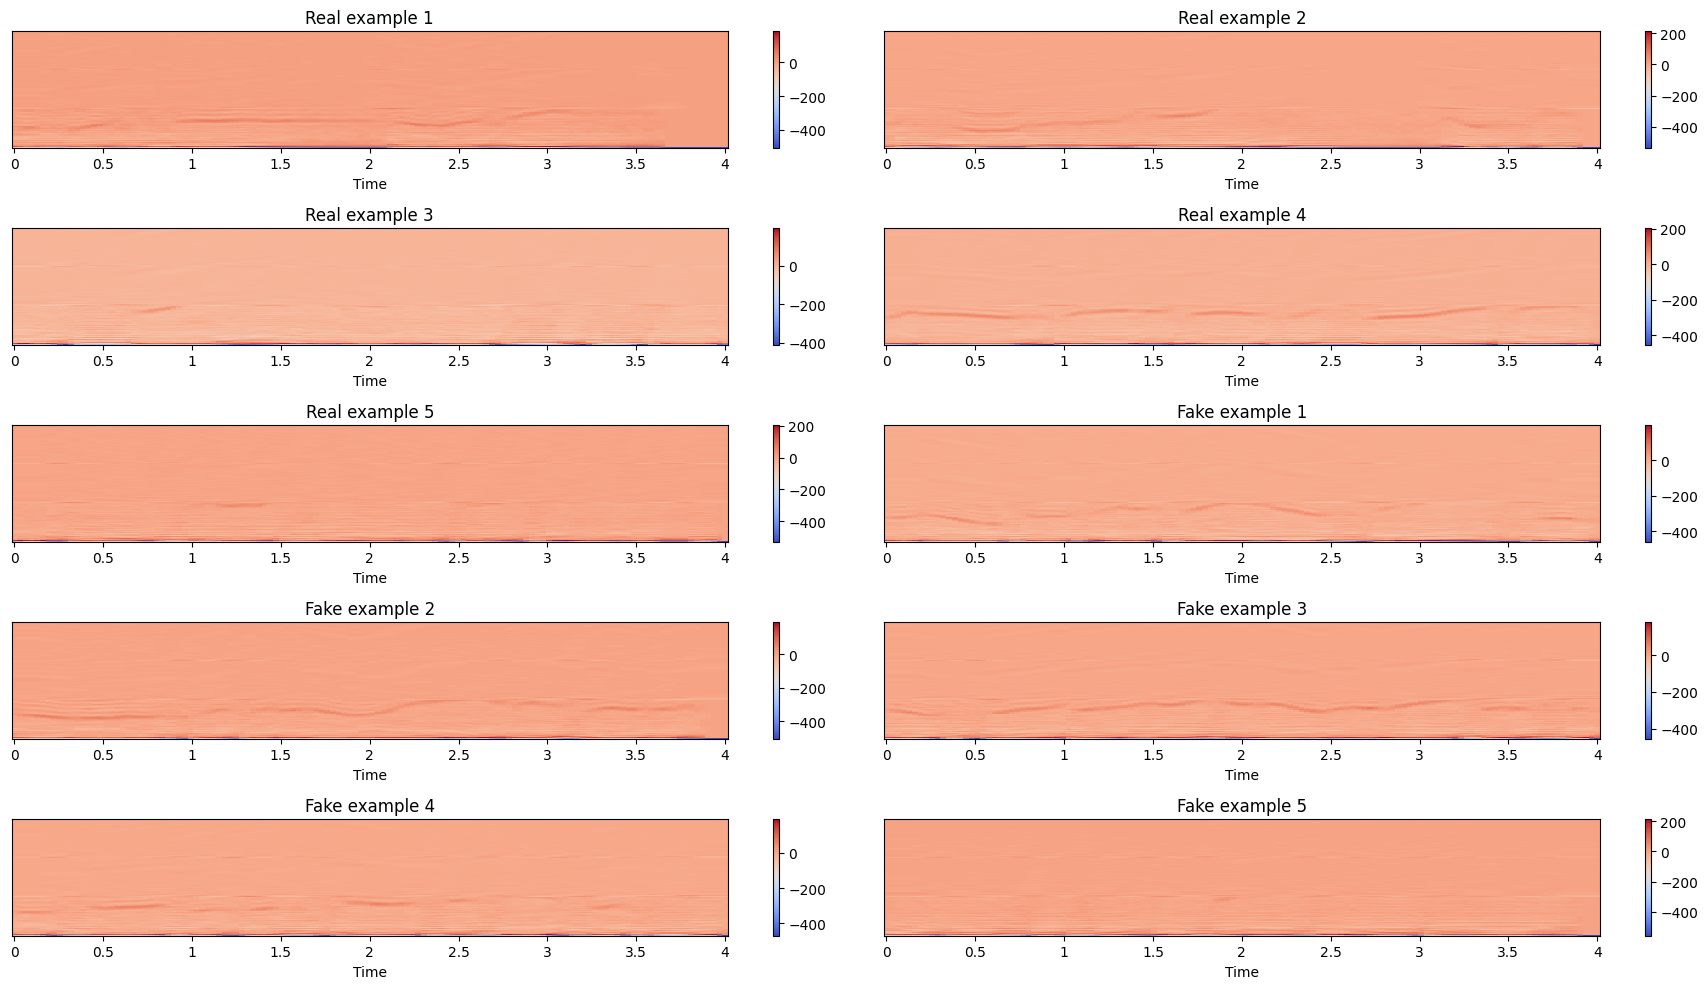

In [37]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(18, 10))

# 5 real
for i in range(5):
    plt.subplot(5, 2, i + 1)
    librosa.display.specshow(mfcc_train[i], sr=16000, x_axis="time")
    plt.title(f"Real example {i+1}")
    plt.colorbar()

# 5 fake
fake_start = labels_train.index(0)

for i in range(5):
    plt.subplot(5, 2, i + 6)
    librosa.display.specshow(mfcc_train[fake_start + i], sr=16000, x_axis="time")
    plt.title(f"Fake example {i+1}")
    plt.colorbar()

plt.tight_layout()
plt.show()

In [38]:
mfcc_val = []
labels_val = []

for fp in val_real:
    mfcc_val.append(create_mfcc_features(fp))
    labels_val.append(1)

for fp in val_fake:
    mfcc_val.append(create_mfcc_features(fp))
    labels_val.append(0)

print("Total validation samples:", len(mfcc_val))

Total validation samples: 2244


In [39]:
mfcc_test = []
labels_test = []

for fp in test_real:
    mfcc_test.append(create_mfcc_features(fp))
    labels_test.append(1)

for fp in test_fake:
    mfcc_test.append(create_mfcc_features(fp))
    labels_test.append(0)

print("Total test samples:", len(mfcc_test))

Total test samples: 816


In [40]:
print("Unique train shapes:", {x.shape for x in mfcc_train})
print("Unique val shapes:", {x.shape for x in mfcc_val})
print("Unique test shapes:", {x.shape for x in mfcc_test})

Unique train shapes: {(120, 126)}
Unique val shapes: {(120, 126)}
Unique test shapes: {(120, 126)}


In [41]:
X_train = np.array(mfcc_train, dtype=np.float32)[..., np.newaxis]
y_train = np.array(labels_train, dtype=np.float32)

X_val = np.array(mfcc_val, dtype=np.float32)[..., np.newaxis]
y_val = np.array(labels_val, dtype=np.float32)

X_test = np.array(mfcc_test, dtype=np.float32)[..., np.newaxis]
y_test = np.array(labels_test, dtype=np.float32)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (10208, 120, 126, 1)
Validation shape: (2244, 120, 126, 1)
Test shape: (816, 120, 126, 1)


In [42]:
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / (std + 1e-8)
X_val   = (X_val - mean) / (std + 1e-8)
X_test  = (X_test - mean) / (std + 1e-8)

print("Train min/max:", X_train.min(), X_train.max())
print("Validation min/max:", X_val.min(), X_val.max())
print("Test min/max:", X_test.min(), X_test.max())

Train min/max: -23.990534 9.442717
Validation min/max: -22.95406 9.128596
Test min/max: -20.595211 8.672847


In [43]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = X_train.shape[1:]

mfcc_cnn = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

mfcc_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

mfcc_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 120, 126, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 63, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │       460,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,161 (1.85 MB)

 Trainable params: 484,161 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_mfcc_cnn.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [45]:
history = mfcc_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.6922 - loss: 0.5744
Epoch 1: val_loss improved from inf to 0.29336, saving model to best_mfcc_cnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 153s 472ms/step - accuracy: 0.6925 - loss: 0.5740 - val_accuracy: 0.8797 - val_loss: 0.2934 - learning_rate: 3.0000e-04
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.8706 - loss: 0.2999
Epoch 2: val_loss improved from 0.29336 to 0.19513, saving model to best_mfcc_cnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 205s 480ms/step - accuracy: 0.8706 - loss: 0.2998 - val_accuracy: 0.9144 - val_loss: 0.1951 - learning_rate: 3.0000e-04
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9054 - loss: 0.2155
Epoch 3: val_loss improved from 0.19513 to 0.14964, saving model to best_mfcc_cnn.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 195s 459ms/step - accuracy: 0.9055 - loss: 0.2155 - val_accuracy: 0.9305 - val_loss: 0.1496 - learning_rate: 3.0000e-04
Epoch 4/10
319/319 ━━━━━━━━━━

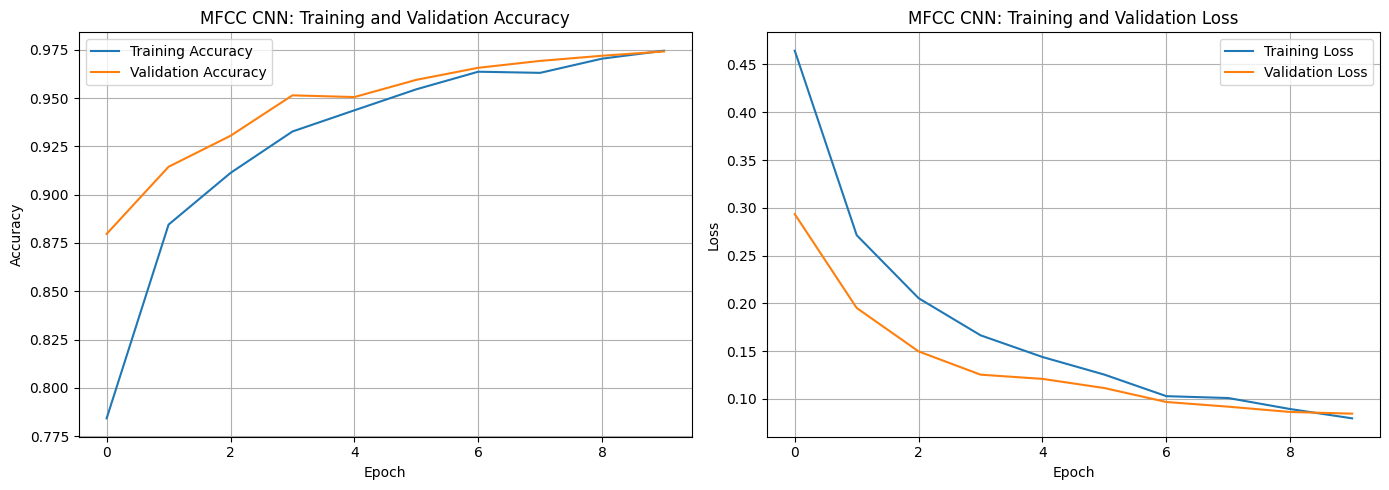

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MFCC CNN: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("MFCC CNN: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [47]:
best_model = tf.keras.models.load_model("best_mfcc_cnn.keras")

test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - accuracy: 0.8695 - loss: 0.3687
Test loss: 0.3374500274658203
Test accuracy: 0.875


26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step


<Figure size 600x600 with 0 Axes>

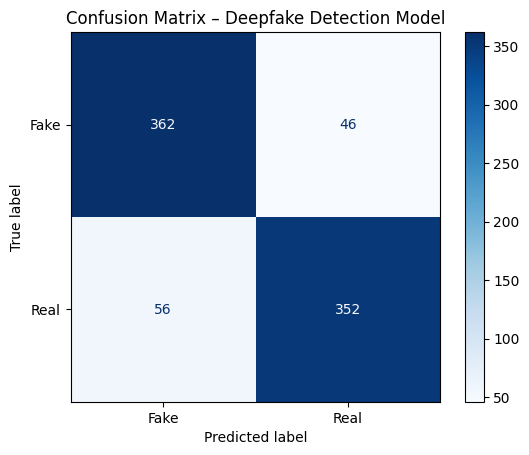

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predict probabilities
y_pred_probs = best_model.predict(X_test)

# Convert probabilities to class labels
y_pred = (y_pred_probs > 0.5).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Deepfake Detection Model")
plt.show()

MFCC representations compress the spectral information of speech and retain the most relevant characteristics of the vocal tract. This reduces noise and irrelevant spectral details, which can improve classification performance when training data is limited. In our experiments, MFCC features resulted in higher classification accuracy compared to mel spectrograms.